### RAG With Persistance Memory Using LangGraph

In [19]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import TypedDict, List
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.messages import SystemMessage
from langgraph.graph import MessagesState, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

In [3]:
llm = init_chat_model("openai:gpt-4o")

In [4]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [5]:
# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

In [7]:
## chunking
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

In [9]:
vector_store=FAISS.from_documents(
    documents=all_splits,
    embedding=OpenAIEmbeddings()
)
print(f"Vector store created with {vector_store.index.ntotal} vectors")

Vector store created with 63 vectors


In [17]:
retriever = vector_store.as_retriever()

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool",
    "Retriever Tool"
)

tools = ToolNode([retriever_tool])

In [13]:
# Step 1: Generate an AIMessage that may include a tool-call to be sent.
def query_or_respond(state: MessagesState):
    """
    Generate tool call for retrieval or respond.
    """
    
    llm_with_tools = llm.bind_tools([retriever_tool])
    response = llm_with_tools.invoke(state["messages"])
    
    # MessagesState appends messages to state instead of overwriting
    return {"messages": [response]}

In [14]:
# Step 3: Generate a response using the retrieved content.
def generate(state: MessagesState):
    """Generate answer."""
    
    # Get generated ToolMessages
    recent_tool_messages = []
    for message in reversed(state["messages"]):
        if message.type == "tool":
            recent_tool_messages.append(message)
        else:
            break
    
    tool_messages = recent_tool_messages[::-1]

    # Format into prompt
    docs_content = "\n\n".join(doc.content for doc in tool_messages)
    
    system_message_content = (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer "
        "the question. If you don't know the answer, say that you "
        "don't know. Use three sentences maximum and keep the "
        "answer concise."
        "\n\n"
        f"{docs_content}"
    )
    conversation_messages = [
        message
        for message in state["messages"]
        if message.type in ("human", "system")
        or (message.type == "ai" and not message.tool_calls)
    ]
    prompt = [SystemMessage(system_message_content)] + conversation_messages

    # Run
    response = llm.invoke(prompt)
    return {"messages": [response]}

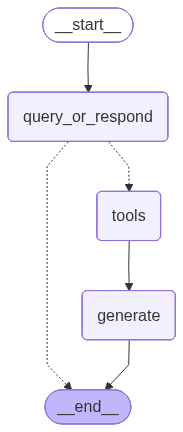

In [21]:
graph_builder = StateGraph(MessagesState)

graph_builder.add_node(query_or_respond)
graph_builder.add_node(tools)
graph_builder.add_node(generate)

graph_builder.set_entry_point("query_or_respond")
graph_builder.add_conditional_edges(
    "query_or_respond",
    tools_condition,
    {END: END, "tools": "tools"},
)
graph_builder.add_edge("tools", "generate")
graph_builder.add_edge("generate", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [22]:
# Specify an ID for the thread
config = {"configurable": {"thread_id": "abc123"}}

In [23]:
input_message="Hello"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I assist you today?


In [24]:
input_message = "What is Task Decomposition?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (call_9a88VTqIVG8Jq2Hu5nAGZmKH)
 Call ID: call_9a88VTqIVG8Jq2Hu5nAGZmKH
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retriever_tool

Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computation to decompose hard tasks into smaller and simpler steps. CoT transforms big tasks into multiple manageable tasks and shed lights into an interpretation of the model’s thinking process.
Tree of Thoughts (Y

In [25]:
input_message = "Can you look up some common ways of doing it?"

for step in graph.stream(
    {"messages": [{"role": "user", "content": input_message}]},
    stream_mode="values",
    config=config,
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

Can you look up some common ways of doing it?
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (call_mUtHMCNGFaGzcdEcZVvNbNmU)
 Call ID: call_mUtHMCNGFaGzcdEcZVvNbNmU
  Args:
    query: common methods of task decomposition
  retriever_tool (call_QAi7HzYUBlizM5ukUa0Ju1rf)
 Call ID: call_QAi7HzYUBlizM5ukUa0Ju1rf
  Args:
    query: task decomposition techniques
================================= Tool Message =================================
Name: retriever_tool

Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.
Another quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. Thi

In [26]:
### Conversation History
chat_history=graph.get_state(config).values["messages"]
for message in chat_history:
    message.pretty_print()

================================ Human Message =================================

Hello
================================== Ai Message ==================================

Hello! How can I assist you today?
================================ Human Message =================================

What is Task Decomposition?
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (call_9a88VTqIVG8Jq2Hu5nAGZmKH)
 Call ID: call_9a88VTqIVG8Jq2Hu5nAGZmKH
  Args:
    query: Task Decomposition
================================= Tool Message =================================
Name: retriever_tool

Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is instructed to “think step by step” to utilize more test-time computatio

### ReAct Agent Architecture-Persistant Memory

In [40]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain.agents import create_agent
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool
from langgraph.checkpoint.memory import MemorySaver

In [28]:
load_dotenv()

True

In [29]:
# setting up environment variables
groq_key = os.getenv("GROQ_API_KEY")
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key is not None:
    os.environ["OPENAI_API_KEY"] = openai_key
else:
    raise ValueError("OPENAI_API_KEY environment variable is not set.")

if groq_key is not None:
    os.environ["GROQ_API_KEY"] = groq_key
else:
    raise ValueError("GROQ_API_KEY environment variable is not set.")

if tavily_key is not None:
    os.environ["TAVILY_API_KEY"] = tavily_key
else: 
    raise ValueError("TAVILY_API_KEY environment variable is not set.")

In [36]:
llm = init_chat_model("openai:gpt-4o")

In [33]:
# Load and chunk contents of the blog
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

In [34]:
## chunking
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

In [39]:
vector_store=FAISS.from_documents(
    documents=all_splits,
    embedding=OpenAIEmbeddings()
)
print(f"Vector store created with {vector_store.index.ntotal} vectors")

Vector store created with 63 vectors


In [41]:
retriever = vector_store.as_retriever()

retriever_tool = create_retriever_tool(
    retriever,
    "retriever_tool",
    "Retriever Tool"
)

In [46]:
agent_executor = create_agent(
    llm,
    [retriever_tool],
    checkpointer=MemorySaver()
)

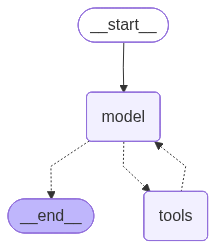

In [47]:
agent_executor

In [48]:
config = {"configurable": {"thread_id": "def234"}}

In [49]:
input_message = (
    "What is the standard method for Task Decomposition?\n\n"
    "Once you get the answer, look up common extensions of that method."
)

In [50]:
for event in agent_executor.stream({"messages": [{"role": "user", "content": input_message}]},
                                   stream_mode="values",
                                   config=config):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the standard method for Task Decomposition?

Once you get the answer, look up common extensions of that method.
================================== Ai Message ==================================
Tool Calls:
  retriever_tool (call_4HxInQ4M8vjtBSy9rTyJHaar)
 Call ID: call_4HxInQ4M8vjtBSy9rTyJHaar
  Args:
    query: Standard method for Task Decomposition
  retriever_tool (call_fcHj1YcczjsMuGfH6Ju1y2HQ)
 Call ID: call_fcHj1YcczjsMuGfH6Ju1y2HQ
  Args:
    query: Common extensions of standard task decomposition method
================================= Tool Message =================================
Name: retriever_tool

Component One: Planning#
A complicated task usually involves many steps. An agent needs to know what they are and plan ahead.
Task Decomposition#
Chain of thought (CoT; Wei et al. 2022) has become a standard prompting technique for enhancing model performance on complex tasks. The model is 